# Task 131: Crowd Congestion Detection System - Standalone Notebook

This Jupyter Notebook is fully self-contained with **ZERO dependencies** on external `.py` files. All logic, helpers, and configurations are defined inside the cells. You can run this top-to-bottom in any standard environment (like Google Colab or local Jupyter).

### Core Pipeline Components:
1. **Config**: YAML configurations defining polygon coordinates and density count thresholds.
2. **Person Detector**: YOLOv8 Wrapper class filtering class 0 (person).
3. **Simple IoU Tracker**: Maintains tracking IDs and centroid coordinates across frames.
4. **Zone Manager**: Spatial point-in-polygon checks and temporal state-machine for congestion hotspots.
5. **Alert Manager**: Structured logging to console and files.
6. **Heatmap Generator**: Color-mapped density heatmap overlays.
7. **Output Writer**: HUD overlays, bounding box annotations, and CSV telemetry.
8. **Pipeline Execution**: The main runner loop processing frames.
9. **Results & Visualizations**: Renders telemetry plots, heatmaps, and alert tables inline.

## 1. Config & Setup

We install the requirements and write a default YAML string representing `config.yaml`. This cell also contains the PyTorch version patch.

In [1]:
# Setup dependencies in fresh environments
# !pip install -q ultralytics opencv-python pandas pyyaml matplotlib numpy

import os
import sys
import cv2
import time
import datetime
import json
import yaml
import glob
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch compatibility patch for ultralytics loading
try:
    _orig_load = torch.load
    def _patched_load(*args, **kwargs):
        kwargs['weights_only'] = False
        return _orig_load(*args, **kwargs)
    torch.load = _patched_load
except Exception:
    pass

# Define Configuration as inline YAML
config_str = """
video_path: "Test_Videos/sample.mp4"
output_dir: "Outputs"
model_path: "Models/yolov8n.pt"

detector:
  confidence_threshold: 0.25

tracker:
  iou_threshold: 0.3
  max_lost_frames: 30

congestion:
  min_duration_seconds: 2.0

heatmap:
  snapshot_interval_seconds: 30.0
  colormap: "COLORMAP_JET"
  alpha: 0.6

zones:
  - name: "Main_Entrance_Zone"
    polygon:
      - [20, 20]
      - [370, 20]
      - [370, 410]
      - [20, 410]
    thresholds:
      low: 2
      moderate: 5
      high: 8
      critical: 10

  - name: "Corridor_Zone"
    polygon:
      - [394, 20]
      - [748, 20]
      - [748, 410]
      - [394, 410]
    thresholds:
      low: 2
      moderate: 5
      high: 8
      critical: 10
"""

standalone_config = yaml.safe_load(config_str)
print("✅ Standalone configuration loaded!")

✅ Standalone configuration loaded!


## 2. Shared Utilities

Contains the frame generator, IoU calculator, and polygon check function.

In [2]:
import os
import cv2
import glob
import numpy as np

# Color definitions for density levels
DENSITY_COLORS = {
    "LOW": (0, 255, 0),       # Green
    "MODERATE": (0, 255, 255), # Yellow
    "HIGH": (0, 165, 255),     # Orange
    "CRITICAL": (0, 0, 255)    # Red
}

def video_frame_generator(video_path):
    """
    Opens a video file or a directory containing sequential images, and yields frames 
    sequentially along with sequence metadata.
    
    Args:
        video_path (str): Path to the input video file or image sequence directory.
        
    Yields:
        tuple: (frame, frame_idx, fps, frame_count, width, height)
    """
    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Input path not found at: {video_path}")
        
    if os.path.isdir(video_path):
        image_extensions = ('*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tif', '*.tiff')
        image_files = []
        for ext in image_extensions:
            image_files.extend(glob.glob(os.path.join(video_path, ext)))
            image_files.extend(glob.glob(os.path.join(video_path, ext.upper())))
            
        image_files = sorted(list(set(image_files)))
        
        if not image_files:
            raise FileNotFoundError(f"No image files found in directory: {video_path}")
            
        frame_count = len(image_files)
        first_frame = cv2.imread(image_files[0])
        if first_frame is None:
            raise IOError(f"Could not read the first image frame: {image_files[0]}")
        height, width = first_frame.shape[:2]
        fps = 30.0  # Default fallback FPS for image sequences
        
        for frame_idx, img_path in enumerate(image_files):
            frame = cv2.imread(img_path)
            if frame is None:
                print(f"⚠️ Warning: Could not read frame image: {img_path}")
                continue
            yield frame, frame_idx, fps, frame_count, width, height
            
    else:
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            raise IOError(f"OpenCV was unable to open the video file at: {video_path}")
            
        try:
            fps = cap.get(cv2.CAP_PROP_FPS)
            if fps <= 0 or fps is None:
                fps = 10.0  # Fallback FPS
                
            frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            
            frame_idx = 0
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                yield frame, frame_idx, fps, frame_count, width, height
                frame_idx += 1
        finally:
            cap.release()

def calculate_iou(box1, box2):
    """
    Computes the Intersection over Union (IoU) between two bounding boxes.
    
    Args:
        box1 (list or tuple): [x1, y1, x2, y2] bounding box coordinates.
        box2 (list or tuple): [x1, y1, x2, y2] bounding box coordinates.
        
    Returns:
        float: IoU value between 0.0 and 1.0.
    """
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    if x2 < x1 or y2 < y1:
        return 0.0
        
    intersection_area = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - intersection_area
    
    if union_area == 0.0:
        return 0.0
        
    return intersection_area / union_area

def is_point_in_polygon(point, polygon):
    """
    Checks if a point (x, y) is inside a polygon using OpenCV's pointPolygonTest.
    
    Args:
        point (tuple or list): (x, y) coordinates of the point.
        polygon (list of list/tuple): Vertices of the polygon [[x1, y1], [x2, y2], ...].
        
    Returns:
        bool: True if point is inside or on the boundary of the polygon, False otherwise.
    """
    poly_array = np.array(polygon, dtype=np.int32)
    # cv2.pointPolygonTest expects a contour of shape (N, 1, 2) or (N, 2)
    # returns positive value if inside, negative value if outside, zero if on edge
    dist = cv2.pointPolygonTest(poly_array, (float(point[0]), float(point[1])), False)
    return dist >= 0


## 3. Person Detector

Loads YOLOv8 and filters class 0 (person).

In [3]:
import os
import sys
import torch
from ultralytics import YOLO



class PersonDetector:
    def __init__(self, model_path="yolov8n.pt", confidence_threshold=0.25):
        """
        Initializes the YOLOv8 detector.
        
        Args:
            model_path (str): Path to the YOLOv8 model weights.
            confidence_threshold (float): Minimum confidence for person detection.
        """
        self.confidence_threshold = confidence_threshold
        
        # Load YOLO model
        if not os.path.exists(model_path):
            # Fallback if model is not in the specified path, it will download
            print(f"⚠️ Model path {model_path} not found. Attempting to download/load default yolov8n.pt")
            self.model = YOLO("yolov8n.pt")
        else:
            self.model = YOLO(model_path)
            
    def detect(self, frame):
        """
        Runs object detection on the frame and filters for 'person' class (COCO class 0).
        
        Args:
            frame (numpy.ndarray): Input video frame (BGR).
            
        Returns:
            list of dict: List of detections. Each detection is:
                {
                    "bbox": [x1, y1, x2, y2],
                    "confidence": float,
                    "class_id": 0
                }
        """
        results = self.model.predict(frame, conf=self.confidence_threshold, verbose=False)
        result = results[0]
        
        detections = []
        if result.boxes is not None and len(result.boxes) > 0:
            boxes = result.boxes.xyxy.cpu().numpy()
            confs = result.boxes.conf.cpu().numpy()
            classes = result.boxes.cls.cpu().numpy()
            
            for idx in range(len(boxes)):
                class_id = int(classes[idx])
                # COCO Class 0 is Person
                if class_id == 0:
                    detections.append({
                        "bbox": [float(val) for val in boxes[idx]],
                        "confidence": float(confs[idx]),
                        "class_id": class_id
                    })
        return detections


## 4. Tracker

Custom lightweight IoU tracker.

In [4]:


class SimpleIoUTracker:
    def __init__(self, iou_threshold=0.3, max_lost_frames=30):
        """
        A lightweight IoU-based tracker for matching detections across frames.
        
        Args:
            iou_threshold (float): Minimum IoU overlap to consider a match.
            max_lost_frames (int): Number of consecutive frames a track can be missing before deletion.
        """
        self.iou_threshold = iou_threshold
        self.max_lost_frames = max_lost_frames
        self.next_id = 1
        self.tracked_persons = {}
        
    def update(self, detections, frame_idx):
        """
        Updates the active tracks with new detections from the current frame.
        
        Args:
            detections (list): List of detections, each is {"bbox": [x1, y1, x2, y2], "confidence": float}
            frame_idx (int): Current frame index.
            
        Returns:
            dict: Currently active tracks visible in this frame.
        """
        active_ids = list(self.tracked_persons.keys())
        matches = []
        
        # Calculate IoU between all current detections and existing tracked persons
        for det_idx, det in enumerate(detections):
            det_bbox = det["bbox"]
            for track_id in active_ids:
                track_bbox = self.tracked_persons[track_id]["bbox"]
                iou = calculate_iou(det_bbox, track_bbox)
                if iou >= self.iou_threshold:
                    matches.append((iou, det_idx, track_id))
                    
        # Sort matches by IoU in descending order
        matches.sort(key=lambda x: x[0], reverse=True)
        
        matched_det_indices = set()
        matched_track_ids = set()
        
        for iou, det_idx, track_id in matches:
            if det_idx in matched_det_indices or track_id in matched_track_ids:
                continue
                
            matched_det_indices.add(det_idx)
            matched_track_ids.add(track_id)
            
            # Update tracked person details
            det = detections[det_idx]
            track_data = self.tracked_persons[track_id]
            track_data["bbox"] = det["bbox"]
            track_data["confidence"] = det["confidence"]
            track_data["lost_frames"] = 0
            track_data["last_seen_frame"] = frame_idx
            
            centroid_x = (det["bbox"][0] + det["bbox"][2]) / 2.0
            centroid_y = (det["bbox"][1] + det["bbox"][3]) / 2.0
            track_data["centroid_history"].append((centroid_x, centroid_y, frame_idx))
            
            if len(track_data["centroid_history"]) > 100:
                track_data["centroid_history"].pop(0)
                
        # Register new tracks for unmatched detections
        for det_idx, det in enumerate(detections):
            if det_idx not in matched_det_indices:
                centroid_x = (det["bbox"][0] + det["bbox"][2]) / 2.0
                centroid_y = (det["bbox"][1] + det["bbox"][3]) / 2.0
                
                self.tracked_persons[self.next_id] = {
                    "bbox": det["bbox"],
                    "confidence": det["confidence"],
                    "centroid_history": [(centroid_x, centroid_y, frame_idx)],
                    "lost_frames": 0,
                    "last_seen_frame": frame_idx
                }
                self.next_id += 1
                
        # Handle lost tracks
        dead_tracks = []
        for track_id in active_ids:
            if track_id not in matched_track_ids:
                self.tracked_persons[track_id]["lost_frames"] += 1
                if self.tracked_persons[track_id]["lost_frames"] > self.max_lost_frames:
                    dead_tracks.append(track_id)
                    
        # Remove dead tracks
        for track_id in dead_tracks:
            del self.tracked_persons[track_id]
            
        # Return tracks present in the current frame
        return {
            tid: data for tid, data in self.tracked_persons.items() 
            if data["last_seen_frame"] == frame_idx
        }


## 5. Zone Manager

Assigns person footprints to zones and monitors congestion using a temporal state machine.

In [5]:
import datetime


class ZoneManager:
    def __init__(self, zone_config, min_duration_seconds=5.0):
        """
        Manages spatial zones, person-to-zone assignment, density levels, 
        and congestion hotspot state transitions.
        
        Args:
            zone_config (list): List of zone dicts from config yaml.
            min_duration_seconds (float): Minimum consecutive seconds to trigger congestion.
        """
        self.zones = zone_config
        self.min_duration_seconds = min_duration_seconds
        
        # State tracking per zone
        self.zone_states = {}
        for zone in self.zones:
            name = zone["name"]
            self.zone_states[name] = {
                "state": "NORMAL",                    # "NORMAL" or "CONGESTED"
                "consec_congested_frames": 0,
                "start_frame_idx": None,
                "start_timestamp": None,
                "peak_count": 0,
                "current_count": 0,
                "current_density": "LOW"
            }
            
        # Callbacks that can be registered by the orchestrator
        self.on_congestion_start_callback = None
        self.on_congestion_end_callback = None
        
        # Complete historical list of congestion events
        self.congestion_history = []
        
    def register_callbacks(self, on_start, on_end):
        """Registers external callback functions for state transitions."""
        self.on_congestion_start_callback = on_start
        self.on_congestion_end_callback = on_end
        
    def update(self, tracked_persons, frame_idx, fps):
        """
        Assigns people to zones, calculates densities, and updates the congestion state machine.
        
        Args:
            tracked_persons (dict): Active tracks from the tracker.
            frame_idx (int): Current video frame index.
            fps (float): Video frames per second.
            
        Returns:
            dict: Current zone states with count, density, and congestion state.
        """
        required_frames = max(1, int(fps * self.min_duration_seconds))
        
        # Reset counts for the current frame
        zone_counts = {zone["name"]: 0 for zone in self.zones}
        
        # Map each tracked person to a zone using bottom-middle point
        for tid, track in tracked_persons.items():
            bbox = track["bbox"]
            # Bottom-middle point of the bounding box
            centroid_x = (bbox[0] + bbox[2]) / 2.0
            centroid_y = bbox[3]
            point = (centroid_x, centroid_y)
            
            for zone in self.zones:
                if is_point_in_polygon(point, zone["polygon"]):
                    zone_counts[zone["name"]] += 1
                    break  # Assign to the first matching zone
                    
        # Update density and state machine for each zone
        for zone in self.zones:
            name = zone["name"]
            count = zone_counts[name]
            thresholds = zone["thresholds"]
            
            # Determine density level
            if count >= thresholds.get("critical", 8):
                density_level = "CRITICAL"
            elif count >= thresholds.get("high", 5):
                density_level = "HIGH"
            elif count >= thresholds.get("moderate", 2):
                density_level = "MODERATE"
            else:
                density_level = "LOW"
                
            state_data = self.zone_states[name]
            state_data["current_count"] = count
            state_data["current_density"] = density_level
            
            is_high_density = (density_level in ["HIGH", "CRITICAL"])
            
            if is_high_density:
                state_data["consec_congested_frames"] += 1
                
                # Check for state transition: NORMAL -> CONGESTED
                if state_data["state"] == "NORMAL":
                    if state_data["consec_congested_frames"] >= required_frames:
                        state_data["state"] = "CONGESTED"
                        # Start frame is when the high density period began
                        state_data["start_frame_idx"] = frame_idx - required_frames + 1
                        state_data["start_timestamp"] = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                        state_data["peak_count"] = count
                        
                        if self.on_congestion_start_callback:
                            self.on_congestion_start_callback(
                                name, 
                                state_data["start_timestamp"], 
                                count, 
                                density_level
                            )
                else:
                    # Keep track of peak count during the event
                    if count > state_data["peak_count"]:
                        state_data["peak_count"] = count
            else:
                # Check for state transition: CONGESTED -> NORMAL
                if state_data["state"] == "CONGESTED":
                    end_timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                    start_frame = state_data["start_frame_idx"]
                    duration = (frame_idx - start_frame) / fps
                    peak = state_data["peak_count"]
                    
                    event = {
                        "zone": name,
                        "start_timestamp": state_data["start_timestamp"],
                        "end_timestamp": end_timestamp,
                        "duration_seconds": float(round(duration, 2)),
                        "peak_count": int(peak)
                    }
                    self.congestion_history.append(event)
                    
                    if self.on_congestion_end_callback:
                        self.on_congestion_end_callback(
                            name, 
                            state_data["start_timestamp"], 
                            end_timestamp, 
                            duration, 
                            peak
                        )
                        
                # Reset counters
                state_data["state"] = "NORMAL"
                state_data["consec_congested_frames"] = 0
                state_data["start_frame_idx"] = None
                state_data["start_timestamp"] = None
                state_data["peak_count"] = 0
                
        return self.zone_states


## 6. Alert Manager

Performs console logs and saves alerts to logs.

In [6]:
import os
import datetime

class AlertManager:
    def __init__(self, log_path="Outputs/alerts.log"):
        """
        Manages alert generation, logging, and external notification routing.
        
        Args:
            log_path (str): File path where alerts will be written.
        """
        self.log_path = log_path
        # Create output directories if needed
        log_dir = os.path.dirname(os.path.abspath(log_path))
        if log_dir:
            os.makedirs(log_dir, exist_ok=True)
            
        # Initialize the log file with a header if it doesn't exist
        if not os.path.exists(self.log_path) or os.path.getsize(self.log_path) == 0:
            with open(self.log_path, 'w') as f:
                f.write("timestamp,zone,event_type,count,duration_seconds\n")
                
    def handle_congestion_start(self, zone_name, timestamp, count, density):
        """
        Handles the start of a congestion event.
        """
        message = f"🚨 [ALERT START] Zone '{zone_name}' is CONGESTED! Count: {count}, Density Level: {density}"
        print(f"\n{message}")
        
        # Log to file
        with open(self.log_path, 'a') as f:
            f.write(f"{timestamp},{zone_name},START,{count},N/A\n")
            
        # Pluggable delivery
        self._send_external_alert(zone_name, "START", count, density=density)
        
    def handle_congestion_end(self, zone_name, start_timestamp, end_timestamp, duration, peak_count):
        """
        Handles the end of a congestion event.
        """
        message = f"✅ [ALERT END] Zone '{zone_name}' congestion resolved. Duration: {duration:.2f}s, Peak Count: {peak_count}"
        print(f"\n{message}")
        
        # Log to file
        with open(self.log_path, 'a') as f:
            f.write(f"{end_timestamp},{zone_name},END,{peak_count},{duration:.2f}\n")
            
        # Pluggable delivery
        self._send_external_alert(zone_name, "END", peak_count, duration=duration)
        
    def _send_external_alert(self, zone_name, event_type, count, density=None, duration=None):
        """
        Pluggable hook for external alert delivery (e.g., Telegram, Slack, Webhook).
        This can be wired to active API endpoints.
        """
        # Hook demonstration output (Console Stub)
        if event_type == "START":
            # For developers to easily wire up later:
            # send_telegram_message(f"ALERT: {zone_name} congested with {count} people.")
            print(f"🔗 [Webhook Hook] Dispatching START alert payload for '{zone_name}' to external notification endpoint...")
        elif event_type == "END":
            # send_slack_message(f"RESOLVED: {zone_name} clear. Dwell: {duration}s.")
            print(f"🔗 [Webhook Hook] Dispatching END alert payload for '{zone_name}' to external notification endpoint...")


## 7. Heatmap Generator

Accumulates centroids and produces blurred colormapped overlays.

In [7]:
import os
import cv2
import numpy as np

class HeatmapGenerator:
    def __init__(self, output_dir="Outputs", colormap="COLORMAP_JET", alpha=0.6, blur_radius=25):
        """
        Accumulates person centroids and generates density heatmaps overlayed on video frames.
        
        Args:
            output_dir (str): Directory where heatmap images will be saved.
            colormap (str): OpenCV colormap name (e.g., COLORMAP_JET).
            alpha (float): Transparency blending factor for the overlay (0.0 to 1.0).
            blur_radius (int): Gaussian blur size for smoothing the accumulated points.
        """
        self.output_dir = output_dir
        self.alpha = alpha
        self.blur_radius = blur_radius if blur_radius % 2 == 1 else blur_radius + 1
        
        # Resolve colormap attribute
        if hasattr(cv2, colormap):
            self.colormap_id = getattr(cv2, colormap)
        else:
            self.colormap_id = cv2.COLORMAP_JET
            
        self.accumulator = None
        self.reference_frame = None
        os.makedirs(self.output_dir, exist_ok=True)
        
    def update(self, tracked_persons, frame):
        """
        Accumulates person centroids in this frame.
        
        Args:
            tracked_persons (dict): Active tracks from the tracker.
            frame (numpy.ndarray): Current video frame to store as reference.
        """
        if self.accumulator is None:
            h, w = frame.shape[:2]
            self.accumulator = np.zeros((h, w), dtype=np.float32)
            
        # Store reference frame (usually the first frame or background)
        if self.reference_frame is None:
            self.reference_frame = frame.copy()
            
        # Accumulate bottom-middle coordinate of each tracked person
        for tid, track in tracked_persons.items():
            bbox = track["bbox"]
            cx = int((bbox[0] + bbox[2]) / 2.0)
            cy = int(bbox[3])
            
            # Bound within frame dimensions
            h, w = self.accumulator.shape
            cx = min(max(0, cx), w - 1)
            cy = min(max(0, cy), h - 1)
            
            # Accumulate a small dot. To make it smooth, we can increment pixels
            # in a small region, or just increment the single pixel and rely on 
            # Gaussian blur later. To make the heatmap look great even for short videos,
            # we draw a small solid circle of radius 5 in each update.
            cv2.circle(self.accumulator, (cx, cy), 8, 1.0, -1)
            
    def generate_heatmap(self, base_image=None):
        """
        Renders the accumulated density as a colormapped heatmap overlay.
        
        Args:
            base_image (numpy.ndarray): Base image to overlay the heatmap on. 
                                        If None, uses the stored reference frame.
                                        
        Returns:
            numpy.ndarray: Colormapped overlay image.
        """
        if self.accumulator is None or np.max(self.accumulator) == 0:
            # If no accumulation occurred, return base image
            return base_image if base_image is not None else self.reference_frame
            
        if base_image is None:
            base_image = self.reference_frame.copy()
            
        # Apply Gaussian blur to smooth the discrete accumulation points
        blurred = cv2.GaussianBlur(self.accumulator, (self.blur_radius, self.blur_radius), 0)
        
        # Normalize to 0-255 range
        max_val = np.max(blurred)
        if max_val > 0:
            normalized = (blurred / max_val * 255).astype(np.uint8)
        else:
            normalized = np.zeros_like(blurred, dtype=np.uint8)
            
        # Apply the colormap
        colored_heatmap = cv2.applyColorMap(normalized, self.colormap_id)
        
        # Create a transparency mask so zero-density areas are not colored blue/cool
        # Mask is based on the normalized values (0 is no density)
        mask = normalized > 5
        
        overlay = base_image.copy()
        # Blend the colored heatmap with the base image in regions where mask is True
        overlay[mask] = cv2.addWeighted(base_image, 1.0 - self.alpha, colored_heatmap, self.alpha, 0)[mask]
        
        return overlay
        
    def save_snapshot(self, filename, base_image=None):
        """
        Generates and saves a heatmap snapshot to the output directory.
        
        Args:
            filename (str): Name of the file to save.
            base_image (numpy.ndarray): Frame to overlay heatmap on.
            
        Returns:
            str: Path of the saved image.
        """
        heatmap_img = self.generate_heatmap(base_image)
        save_path = os.path.join(self.output_dir, filename)
        cv2.imwrite(save_path, heatmap_img)
        return save_path


## 8. Output Writer

Annotates frames with HUD, boxes, and zone colors. Writes telemetry logs.

In [8]:
import os
import cv2
import pandas as pd
import numpy as np


class OutputWriter:
    def __init__(self, video_output_path, csv_output_path, fps, width, height):
        """
        Manages the writing of the annotated output video and the CSV telemetry logs.
        
        Args:
            video_output_path (str): File path for the output MP4 video.
            csv_output_path (str): File path for the output CSV telemetry.
            fps (float): Frame rate of the video.
            width (int): Frame width.
            height (int): Frame height.
        """
        self.video_output_path = video_output_path
        self.csv_output_path = csv_output_path
        self.fps = fps
        self.width = width
        self.height = height
        
        # Create output directories if needed
        os.makedirs(os.path.dirname(os.path.abspath(self.video_output_path)), exist_ok=True)
        os.makedirs(os.path.dirname(os.path.abspath(self.csv_output_path)), exist_ok=True)
        
        # Initialize video writer
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        self.out_writer = cv2.VideoWriter(self.video_output_path, fourcc, self.fps, (self.width, self.height))
        
        # Initialize CSV log file with header
        with open(self.csv_output_path, 'w') as f:
            f.write("timestamp,frame_number,zone,crowd_count,congestion_level,is_congested\n")
            
    def write_telemetry(self, timestamp_str, frame_idx, zone_states):
        """
        Appends crowd telemetry to the CSV file.
        """
        with open(self.csv_output_path, 'a') as f:
            for name, state in zone_states.items():
                is_congested_val = 1 if state["state"] == "CONGESTED" else 0
                f.write(f"{timestamp_str},{frame_idx},{name},{state['current_count']},{state['current_density']},{is_congested_val}\n")
                
    def annotate_frame(self, frame, tracked_persons, zone_states, zones):
        """
        Draws premium annotations on the frame:
        - Bounding boxes with IDs.
        - Semi-transparent filled zone polygons.
        - HUD overlay displaying status for all zones.
        - System alert banner if any zone is congested.
        
        Args:
            frame (numpy.ndarray): The raw BGR frame.
            tracked_persons (dict): Active tracked persons in the current frame.
            zone_states (dict): Current states of all zones.
            zones (list): List of zone geometries.
            
        Returns:
            numpy.ndarray: Annotated frame.
        """
        annotated = frame.copy()
        h, w = frame.shape[:2]
        
        # 1. Draw Semi-Transparent Zone Polygons
        overlay = annotated.copy()
        for zone in zones:
            name = zone["name"]
            polygon = np.array(zone["polygon"], dtype=np.int32)
            state = zone_states[name]
            density = state["current_density"]
            color = DENSITY_COLORS.get(density, (0, 255, 0))
            
            # Fill polygon semi-transparently
            cv2.fillPoly(overlay, [polygon], color)
            
            # Draw boundary line
            thickness = 3 if state["state"] == "CONGESTED" else 2
            cv2.polylines(annotated, [polygon], True, color, thickness)
            
            # Add a small label in the center/centroid of the zone for readability
            moments = cv2.moments(polygon)
            if moments["m00"] != 0:
                cx = int(moments["m10"] / moments["m00"])
                cy = int(moments["m01"] / moments["m00"])
                label = f"{name}"
                cv2.putText(annotated, label, (cx - 40, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 2)
                cv2.putText(annotated, label, (cx - 40, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
                
        # Blend the filled polygon overlay
        alpha = 0.15  # subtle transparency
        cv2.addWeighted(overlay, alpha, annotated, 1.0 - alpha, 0, annotated)
        
        # 2. Draw Person Bounding Boxes
        for tid, track in tracked_persons.items():
            bbox = track["bbox"]
            x1, y1, x2, y2 = map(int, bbox)
            
            # Draw bbox
            box_color = (255, 200, 0) # Sleek blue/cyan
            cv2.rectangle(annotated, (x1, y1), (x2, y2), box_color, 2)
            
            # Centroid dot
            cx = (x1 + x2) // 2
            cy = y2
            cv2.circle(annotated, (cx, cy), 4, (0, 0, 255), -1)
            
            # Bbox label (ID)
            label = f"ID {tid}"
            (lw, lh), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.4, 1)
            cv2.rectangle(annotated, (x1, y1 - lh - 6), (x1 + lw + 6, y1), box_color, -1)
            cv2.putText(annotated, label, (x1 + 3, y1 - 3), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 0), 1, cv2.LINE_AA)
            
        # 3. HUD Overlay (Top-Right Panel)
        hud_w, hud_h = 240, 30 + len(zones) * 30
        hud_x, hud_y = w - hud_w - 15, 15
        
        # Semi-transparent background
        hud_bg = annotated.copy()
        cv2.rectangle(hud_bg, (hud_x, hud_y), (hud_x + hud_w, hud_y + hud_h), (30, 30, 30), -1)
        cv2.addWeighted(hud_bg, 0.8, annotated, 0.2, 0, annotated)
        cv2.rectangle(annotated, (hud_x, hud_y), (hud_x + hud_w, hud_y + hud_h), (100, 100, 100), 1)
        
        # HUD Header
        cv2.putText(annotated, "ZONE LIVE MONITOR", (hud_x + 10, hud_y + 20), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)
        cv2.line(annotated, (hud_x + 10, hud_y + 25), (hud_x + hud_w - 10, hud_y + 25), (100, 100, 100), 1)
        
        # HUD Rows
        for i, zone in enumerate(zones):
            name = zone["name"]
            state = zone_states[name]
            count = state["current_count"]
            density = state["current_density"]
            color = DENSITY_COLORS.get(density, (255, 255, 255))
            
            # Shorten name if too long
            short_name = name[:15]
            row_y = hud_y + 45 + i * 25
            
            # Draw indicator circle
            cv2.circle(annotated, (hud_x + 20, row_y - 4), 6, color, -1)
            
            # Zone info text
            txt = f"{short_name}: {count} ({density})"
            cv2.putText(annotated, txt, (hud_x + 35, row_y), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (240, 240, 240), 1, cv2.LINE_AA)
            
            # Highlight if congested
            if state["state"] == "CONGESTED":
                cv2.putText(annotated, "⚠️ CONGESTED", (hud_x + 155, row_y), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0, 0, 255), 1, cv2.LINE_AA)
                
        # 4. Global Alert Banner (Top-Center) if any zone is congested
        any_congested = any(s["state"] == "CONGESTED" for s in zone_states.values())
        if any_congested:
            banner_h = 35
            banner_bg = annotated.copy()
            cv2.rectangle(banner_bg, (0, 0), (w, banner_h), (0, 0, 220), -1) # Sleek Red
            cv2.addWeighted(banner_bg, 0.85, annotated, 0.15, 0, annotated)
            
            alert_text = "⚠️ CRITICAL SYSTEM WARNING: ACTIVE CROWD CONGESTION DETECTED"
            (tw, th), _ = cv2.getTextSize(alert_text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)
            cv2.putText(annotated, alert_text, ((w - tw) // 2, (banner_h + th) // 2), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2, cv2.LINE_AA)
            
        return annotated
        
    def write_frame(self, frame):
        """Writes the annotated frame to the output video."""
        self.out_writer.write(frame)
        
    def close(self):
        """Releases the video writer resource."""
        if self.out_writer is not None:
            self.out_writer.release()
            self.out_writer = None


## 9. Pipeline Execution

Main runner function orchestrating the components.

In [9]:
def run_standalone_pipeline(config_dict):
    video_path = config_dict.get("video_path", "Test_Videos/sample.mp4")
    if not os.path.exists(video_path) and os.path.exists(os.path.join("..", video_path)):
        video_path = os.path.join("..", video_path)
        
    output_dir = config_dict.get("output_dir", "Outputs")
    if not os.path.isabs(output_dir):
        output_dir = os.path.abspath(os.path.join(os.path.dirname("."), output_dir))
    os.makedirs(output_dir, exist_ok=True)
    
    model_path = config_dict.get("model_path", "Models/yolov8n.pt")
    if not os.path.exists(model_path) and os.path.exists(os.path.join("..", model_path)):
        model_path = os.path.join("..", model_path)
        
    print(f"🎬 Processing Video: {video_path}")
    
    detector = PersonDetector(model_path=model_path, confidence_threshold=config_dict['detector']['confidence_threshold'])
    tracker = SimpleIoUTracker(iou_threshold=config_dict['tracker']['iou_threshold'], max_lost_frames=config_dict['tracker']['max_lost_frames'])
    zone_manager = ZoneManager(zone_config=config_dict['zones'], min_duration_seconds=config_dict['congestion']['min_duration_seconds'])
    alert_manager = AlertManager(log_path=os.path.join(output_dir, "alerts.log"))
    
    zone_manager.register_callbacks(on_start=alert_manager.handle_congestion_start, on_end=alert_manager.handle_congestion_end)
    
    heatmap_gen = HeatmapGenerator(output_dir=output_dir, colormap=config_dict['heatmap']['colormap'], alpha=config_dict['heatmap']['alpha'])
    
    start_time = time.time()
    processed_frames = 0
    writer = None
    
    frame_generator = video_frame_generator(video_path)
    snapshot_interval = config_dict['heatmap']['snapshot_interval_seconds']
    
    for frame, frame_idx, fps, frame_count, width, height in frame_generator:
        if writer is None:
            writer = OutputWriter(
                video_output_path=os.path.join(output_dir, "sample_annotated.mp4"),
                csv_output_path=os.path.join(output_dir, "crowd_density.csv"),
                fps=fps, width=width, height=height
            )
            
        detections = detector.detect(frame)
        active_tracks = tracker.update(detections, frame_idx)
        zone_states = zone_manager.update(active_tracks, frame_idx, fps)
        
        annotated_frame = writer.annotate_frame(frame, active_tracks, zone_states, config_dict['zones'])
        writer.write_frame(annotated_frame)
        
        elapsed_sec = frame_idx / fps
        td = datetime.timedelta(seconds=elapsed_sec)
        video_time_str = str(td).split('.')[0]
        writer.write_telemetry(video_time_str, frame_idx, zone_states)
        
        heatmap_gen.update(active_tracks, frame)
        
        if snapshot_interval > 0 and frame_idx > 0 and int(frame_idx) % int(fps * snapshot_interval) == 0:
            snap_num = int(frame_idx // (fps * snapshot_interval))
            heatmap_gen.save_snapshot(f"heatmap_snapshot_{snap_num:03d}.png", frame)
            
        processed_frames += 1
        
    if writer is not None:
        writer.close()
    heatmap_gen.save_snapshot("heatmap_final.png")
    
    elapsed_time = time.time() - start_time
    avg_fps = processed_frames / elapsed_time
    print(f"\n🎉 Standalone Pipeline Completed in {elapsed_time:.2f}s ({avg_fps:.2f} FPS)")
    
run_standalone_pipeline(standalone_config)

🎬 Processing Video: ..\Test_Videos/sample.mp4



🎉 Standalone Pipeline Completed in 101.98s (13.67 FPS)


## 10. Results & Visualizations

Renders the crowd count curves, final density heatmap, and alert logs inline.

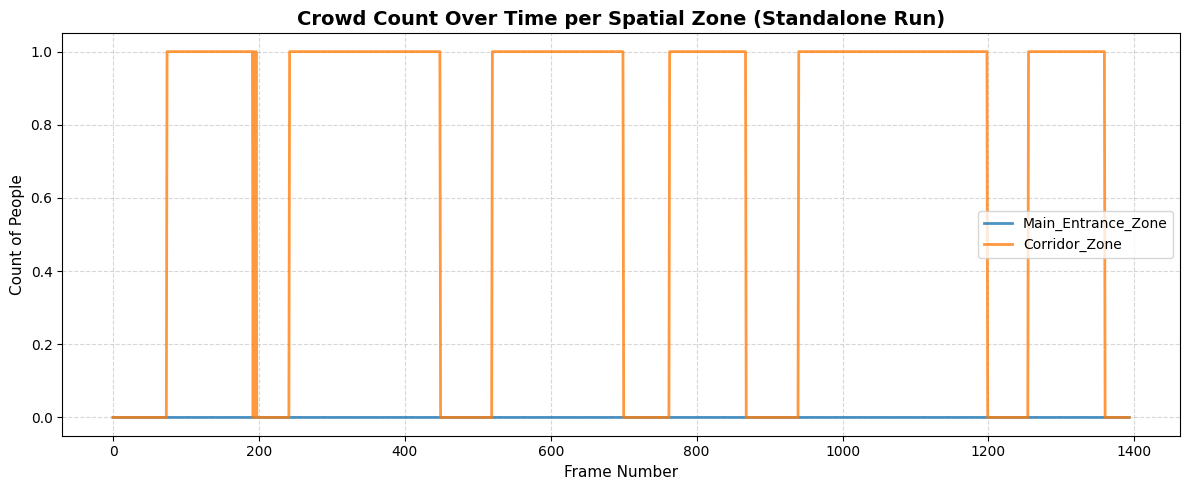

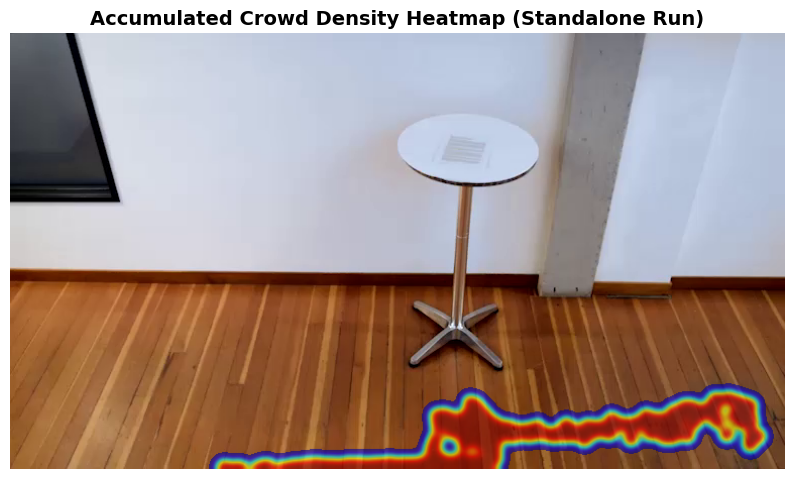

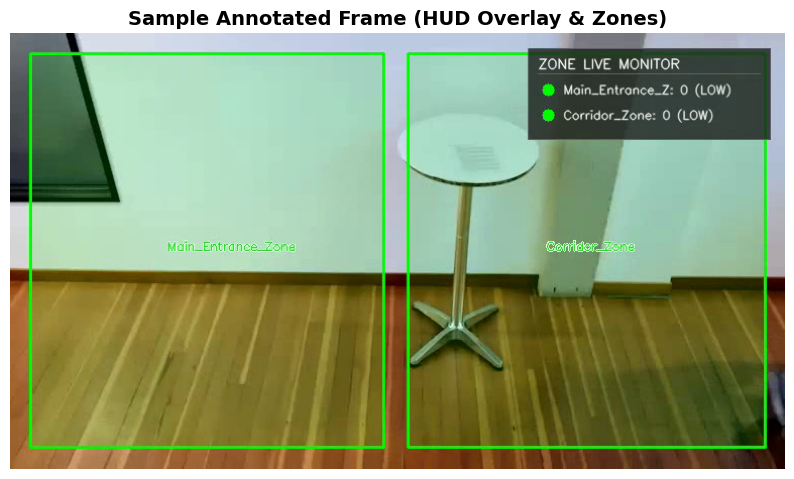


🚨 Congestion Alerts Log:


,timestamp,zone,event_type,count,duration_seconds
0,2026-06-30 14:28:51,Corridor_Zone,START,1,NaN
1,2026-06-30 14:28:58,Corridor_Zone,END,1,11.8
2,2026-06-30 14:29:03,Corridor_Zone,START,1,NaN
3,2026-06-30 14:29:15,Corridor_Zone,END,1,20.7
4,2026-06-30 14:29:19,Corridor_Zone,START,1,NaN
5,2026-06-30 14:29:28,Corridor_Zone,END,1,18.0
6,2026-06-30 14:29:33,Corridor_Zone,START,1,NaN
7,2026-06-30 14:29:38,Corridor_Zone,END,1,10.5
8,2026-06-30 14:29:44,Corridor_Zone,START,1,NaN
9,2026-06-30 14:29:59,Corridor_Zone,END,1,25.9


In [10]:
output_dir = standalone_config.get("output_dir", "Outputs")
csv_path = os.path.join(output_dir, "crowd_density.csv")
df = pd.read_csv(csv_path)

# 1. Plot Telemetry Curves
plt.figure(figsize=(12, 5))
for zone_name in df['zone'].unique():
    zone_df = df[df['zone'] == zone_name]
    plt.plot(zone_df['frame_number'], zone_df['crowd_count'], label=zone_name, alpha=0.8, linewidth=2)
    
plt.title("Crowd Count Over Time per Spatial Zone (Standalone Run)", fontsize=14, fontweight='bold')
plt.xlabel("Frame Number", fontsize=11)
plt.ylabel("Count of People", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# 2. Render Heatmap Inline
heatmap_path = os.path.join(output_dir, "heatmap_final.png")
if os.path.exists(heatmap_path):
    img = cv2.imread(heatmap_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.title("Accumulated Crowd Density Heatmap (Standalone Run)", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

# 3. Render Sample Video Frame Inline (to check annotations)
video_out_path = os.path.join(output_dir, "sample_annotated.mp4")
if os.path.exists(video_out_path):
    cap = cv2.VideoCapture(video_out_path)
    # Seek to middle of the video (approx frame 700)
    cap.set(cv2.CAP_PROP_POS_FRAMES, 700)
    ret, frame = cap.read()
    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 6))
        plt.imshow(frame_rgb)
        plt.title("Sample Annotated Frame (HUD Overlay & Zones)", fontsize=14, fontweight='bold')
        plt.axis('off')
        plt.show()
    cap.release()

# 4. Display Alerts Log
alerts_path = os.path.join(output_dir, "alerts.log")
if os.path.exists(alerts_path):
    alerts_df = pd.read_csv(alerts_path)
    if len(alerts_df) > 0:
        print("\n🚨 Congestion Alerts Log:")
        display(alerts_df)
    else:
        print("No congestion events recorded.")